# Uncertainties in Gaussian spectra

The goal of this notebook is to gather my thoughts about uncertainties in gaussian spectra, such as encountered in water waves in the ocean (though this will apply to any phenomenon that follows a stochastic gaussian process and is analyzed with a spectrum DFT based method). The demonstrations are not included, to keep the explanation short and readable - the goal is to give a "physicist's explanation" of what one's intuition and main things to keep in mind should be. Somehow, so far, either I was only finding too shallow / "beginner level" materials, or I was finding full detail textbook, nothing "in the middle" that I can read fast to refresh my mind, get all the information I need, but within just a few pages not a full book. This is what I attempt here.

For more information, see a course on DFT / signal analysis or just ask any AI - they know all of this very well. Typically, this assumes that one already has a diffuse understanding and knows the main notions, and just needs a straight easy-to-read self-contained main-points writeup. For more details / explanations / more advanced formula that are only mentioned not written, read a textbook or ask AI.

## A bit of theory

### Fundamentals of gaussian stochastic signals analysis with DFT / iDFT

We consider a physical phenomenon that follows a stochastic process, stationary over the sampling time considered, resulting in an observable time series $x(t)$, with $t$ the time. The phenomenon is sampled over discrete time samples $t_n$, $n=0..N-1$, equally spaced in time (spacing $dt$, sampling frequency $f_s = 1 / dt$) for simplicity, so $t_n=n dt$ and the total signal duration is $T = N dt$. The underlying stochastic process is unknown - all what we have access to, is an individual realization of the stochastic process, through the discrete time series samples of the $x(t_n)$. In the following, we write like a physicist, and sometimes we write $x_n$ (resp. $X_k$), sometimes we write $x(t_n)$ (resp. $X(f_k)$), referring to the value at a point in time or by index. The operators sending between time and frequency are written $\mathrm{DFT}$ and $\mathrm{iDFT}$. We write $\mathrm{var}(\cdot)$ for the variance (quadratic in the quantity) and $\sigma(\cdot)$ for the standard deviation (the square root of the variance, homogeneous in the quantity); these are not interchangeable.

Given the time series samples, one maps the realization to frequency with the discrete Fourier transform (DFT) at $f_k = k / T$. A caveat on language: a (wide-sense) stationary process does *not* have ordinary Fourier coefficients — it is not a finite-energy deterministic signal. What exists is a power spectrum, estimated later by the periodogram. The DFT of one record is just that record in the Fourier basis; the process itself stays hidden. (As a note, $f_k = k / T$ is only strictly valid for $k=0..\lfloor N/2 \rfloor$; for $k=\lfloor (N+1)/2 \rfloor..N-1$, the frequencies wrap, so the frequency effectively sampled is the negative frequency $f_k = (k-N) / T$):

$X(f_k) = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x(t_n) e^{-i 2 \pi k n / N}$, with $k=0..N-1$.

The inverse DFT (iDFT) is then:

$x(t_n) = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X(f_k) e^{i 2 \pi k n / N}$, with $n=0..N-1$,

so that $\mathrm{iDFT} \circ \mathrm{DFT} = \mathrm{DFT} \circ \mathrm{iDFT} = \mathrm{Id}$, with $\mathrm{Id}$ the identity.

Note that the $x(t_n)$ and $X(f_k)$ are in general complex. In the case when $x$ is real, $X$ is hermitian, i.e. $X_k = X^*_{N-k \bmod N}$ (the $\bmod N$ covers the special case that $X_0$ is real, and that there is no $X_N$; when $N$ is even, $X_{N/2}$ is also real). This means one needs to remember to take moduli and consider both real and imaginary parts of both $x$ and $X$ as needed depending on the case considered.

The Parseval theorem guarantees to us that $\sum_{n=0}^{N-1} |x(t_n)|^2 = \sum_{k=0}^{N-1} |X(f_k)|^2$ . This means that, effectively, the DFT and iDFT with proper normalization conserve energy, and the signal $x$ shows the distribution of signal energy across time, while $X$ shows the distribution of signal energy across frequencies.

Note that the conventions on the DFT and inverse DFT (sign, normalization coefficients splitting between the DFT and iDFT, how the $N$ samples in time or frequency are stored as arrays and how the negative frequency are wrapped, specific behavior for real / hermitian inputs, etc) can change between textbooks / software packages etc: read the documentation of your package and have consistency tests! In this note we use *per-bin* energies ($\hat{S}_k = |X_k|^2$), so that Parseval is $\sum_n |x_n|^2 = \sum_k \hat{S}_k$. Some texts and packages instead quote a spectral *density* (energy per Hz), obtained from the per-bin quantity by dividing by $f_s$ (equivalently multiplying by $dt$); relative uncertainties are the same either way.

Using the DFT above, one can formulate a discrete estimator $\hat{S}$ for the underlying, hidden power spectrum of the stochastic process, called the periodogram, defined per bin as: $\hat{S}_k = |X_k|^2$. We write $S_k$ for the corresponding true bin powers ($\hat{S}_k$ estimates $S_k$). Note that $\hat{S}$ is only an estimator (see more about its properties below)!

Also note that there are "balances" / "equivalences" between how things are sampled in time and frequency: given $T = N dt$ the duration of the time series sampled, $N$ the number of sample points, $dt$ the sampling interval time, $f_s = 1 / dt$ the sampling rate, $df$ the DFT resolution:

- the highest frequency one can get an estimator for depends only on the sample rate (Nyquist frequency): $f_{max} = f_s / 2$
- the frequency resolution of a DFT of a record of duration $T$ depends only on that duration: $df = 1 / T$. This is for the DFT of *that* array. In the Welch method below, each FFT is taken on a segment of duration $T_{\mathrm{seg}} = n_{\mathrm{perseg}}\, dt$, so the resolution is $df = 1 / T_{\mathrm{seg}} = f_s / n_{\mathrm{perseg}}$, not $1 / T_{\mathrm{total}}$
- the number of DFT bins is $f_s / df = N$, with $N$ the length of the array being transformed (the full record, or $n_{\mathrm{perseg}}$ for Welch). The ratio $f_{max} / df = N/2$ is the number of bins from DC up to Nyquist. For a complex signal $x$, all $N$ bins are unique. For a real signal $x$, the DFT $X$ is hermitian, and there are only $N/2 + 1$ unique frequency bins (DC, positive frequencies, and Nyquist if $N$ is even).

In practice, the formula for the DFT and iDFT presented above are not how these are computed - these formula would be quadratic (complexity $\mathcal{O}(n^2)$ for computing the full array transform), while the discrete version of the fast Fourier transform (FFT) uses divide-and-conquer radix-based approaches to perform the same computation (implemented differently) in log-linear time (complexity $\mathcal{O}(n \log(n))$), with different prefactors depending on signal length and radix implementation - use a dedicated package, typically wrapping FFTW or similar!

### Uncertainties on the DFT spectrum estimator

Often, a goal in signal analysis is to estimate the power spectrum of a stochastic signal, and the periodogram $\hat{S}$ is used as an estimator (possibly with tapering, segmenting, and averaging - see the next section) for that. (In the continuous-time literature this spectrum is often the spectral *density*: the Fourier transform of the autocorrelation function. That density $S(f)$ is the per-bin $S_k$ divided by $f_s$; we stay per-bin.) As highlighted above, this is only an estimator, so it comes with uncertainties. In the following, we will consider that the underlying stochastic process is gaussian. This is generally a reasonable first approximation / model, as gaussianity naturally arises in many processes due to the central limit theorem (i.e., the average summation of very many independent identically distributed variables converges towards a gaussian distribution), though it may break down if some nonlinearity, coupling, etc, arises between the variables considered (for example, it is well established empirically that the stock market is usually log-normal, but this does not hold when a major event happens and individual stocks start responding in unison to a specific shock). A practical red flag in spectra: a narrow-band peak plus a harmonic lobe is often quadratic / Stokes-type nonlinearity — which is exactly when the Gaussian-process $\chi^2$ model is weakest. The harmonic can be a real spectral feature and still not be a Gaussian-process bin.

The periodogram $\hat{S}$ is asymptotically unbiased for the true underlying per-bin powers $S_k$ in the following sense:

$S_k = \lim_{T \to \infty} \mathbb{E} [\hat{S}_k]$ .

(If one normalizes to density, the same statement would read $f_s \cdot S(f_k) = \lim_{T \to \infty} \mathbb{E} [\hat{S}_k]$ with our $\hat{S}_k = |X_k|^2$, or equivalently one defines a density periodogram $|X_k|^2 / f_s$.)

This is a statement about the expectation, not about a single realization: as $T \to \infty$, $\mathrm{var}(\hat{S}_k)$ does not go to $0$, so the raw periodogram is not a consistent estimator. Two distinct issues are easy to mix up. (1) *Bias / smoothing*: at finite $T$, $\mathbb{E}[\hat{S}_k]$ is not $S_k$ pointwise, but $S$ convolved with the Fejér kernel of the rectangular tap (spectral leakage / resolution bias). That bias vanishes only as $df = 1/T \to 0$ with $S$ smooth, and is a property of the *expectation*. (2) *Variance*: the $\chi^2$ fluctuations of a single periodogram do *not* vanish as $T$ grows — that is why one averages segments. The $T \to \infty$ statement is also hard in practice because the record must remain stationary, and because it is about $\mathbb{E}[\hat{S}_k]$ (many realizations, or equivalent averaging).

This highlights that $\hat{S}$ is only a stochastic estimator for the underlying per-bin spectrum $S$, which is asymptotically unbiased. Therefore, one needs to estimate the uncertainty associated with this estimator. Given that the underlying stochastic process is gaussian, the periodogram at each frequency bin is computed from the combination of the 2 real-valued coefficients (real part and imaginary part) obtained from the DFT:

$\hat{S}_k = a_k^2 + b_k^2$, where $a_k$ and $b_k$ are the real and imaginary part of the associated DFT output ($a_k = \mathrm{Re}(X_k)$, $b_k = \mathrm{Im}(X_k)$).

As the underlying stochastic process is gaussian, this means that taken individually, $a_k$ and $b_k$ follow a gaussian distribution. As a result, $\hat{S}_k$ follows a (scaled) chi-squared distribution with 2 degrees of freedom — except at the DC bin $k=0$ and, when $N$ is even, the Nyquist bin $k=N/2$, where $X_k$ is real and there is only 1 degree of freedom. The properties of the chi-squared distribution with 2 degrees of freedom are such that:

$\mathrm{var}(\hat{S}_k) = S_k^2$, hence $\sigma(\hat{S}_k) = S_k$. As $\hat{S}_k$ is our estimator for $S_k$, the estimator for $\mathrm{var}(\hat{S}_k)$ is $\hat{S}_k^2$, and the estimator for the standard deviation is $\hat{S}_k$ itself (relative uncertainty of $100\%$). Because this chi-squared (exponential) distribution is strongly skewed, a symmetric $\pm \sigma$ interval is a poor description of the uncertainty: $\hat{S}_k \pm \hat{S}_k$ is a Gaussian-style shorthand, not a confidence interval.

The usable statement comes from inverting the chi-squared law. In general (raw periodogram: $\nu=2$ at interior bins; $\nu=1$ at DC, and at Nyquist when $N$ is even)

$\hat{S}_k \sim S_k \cdot \chi^2_{\nu} / \nu$,

so $\nu \hat{S}_k / S_k \sim \chi^2_{\nu}$. A two-sided interval at level $1-\alpha$ is therefore

$S_k \in \left[ \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,1-\alpha/2}},\; \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,\alpha/2}} \right]$,

where $\chi^2_{\nu,q}$ is the $q$-quantile of $\chi^2_{\nu}$. The lower bound on $S_k$ uses the *upper* quantile of $\chi^2_{\nu}$, and conversely: that is just inverting $\nu \hat{S}_k / S_k$. For the raw periodogram ($\nu=2$, $\alpha=0.05$) this is about $[0.27\,\hat{S}_k,\, 39\,\hat{S}_k]$ — far from $\hat{S}_k \pm \hat{S}_k$. Averaging (next section) only changes $\nu$; the same formula applies. This means, in practice, that the estimator $\hat{S}$ comes with considerable uncertainty as a result of the nature of the underlying gaussian process, and how this estimator works. This explains why the DFT-based non-averaged periodogram of a timeseries that is a realization of a gaussian stochastic process is typically very "spiky".

### Tapering, segmenting and averaging, combining both in the Welch method estimator, and Welch periodogram uncertainty

#### Tapering

There are some additional assumptions that are implicitly baked into the analysis above. While the mathematics will work for any input signal provided as an array to the DFT or iDFT operator, these are typically discrete variants of the continuous Fourier transforms. These typically assume (to make the theory work) / work best (in practice) with periodic signals, and running these with a signal that is not periodic ($x_0 \neq x_{N-1}$) typically results in Gibbs-like oscillatory phenomenon / spectral leakage, meaning energy that should be concentrated in a specific bin, diffuses to neighboring bins.

To avoid this phenomenon, and since most real world signals are not truly periodic, one generally uses tapering: instead of computing:

$X = \mathrm{DFT}(x)$,

One computes:

$X^{(w)} = \mathrm{DFT}(w \cdot x)$, where $w$ is a tapering function (often called a "window" in DSP; here "window" in that sense means the taper, not a time segment). There are several tapering functions available, with different tradeoffs between in particular spectral leaking / amplitude accuracy, vs frequency resolution: typically, one cannot achieve at the same time high frequency resolution (getting narrow lobe where the energy is concentrated) and low spectral leaking (getting energy diffused into side lobes). See for example the tradeoffs between rectangular tapering (equivalent to no tapering), Hann, Hamming, Blackman-Harris, and more - depending on the application, one or another may offer a better tradeoff.

These tapering functions typically all look like "hats", which make the initial signal go smoothly (or not) to $0$ for the first and last index, while keeping the middle of the array unchanged. In practice, these are often available directly through software packages. How far the "hat" goes to zero at the left and right, the shape of the transitions, etc, is what decide the tradeoffs between different taperings.

#### Segmenting and averaging

A common way to reduce variance of an estimate is to perform averaging - the key result is that, averaging a random variable following a given distribution by sampling it independently $p$ times and doing an equally weighted average, reduces the variance by a factor $1/p$ compared to the individual variance of each sample (this works for any underlying distribution and is just simple arithmetics on the variance of the averaging formula). Said otherwise, the standard deviation of the independently-sampled, $p$-average estimator is $1/\sqrt{p}$ that of the 1-sample estimator. In addition, a second phenomenon takes place due to the central limit theorem: as $p$ is increased, the distribution followed by each $p$-averaged bin transitions from a chi-squared distribution (exact for a gaussian stochastic process and $p=1$), to a gaussian distribution (asymptotic behavior as $p \to \infty$). This happens gradually, and there are formula to quantify this convergence from chi-squared to Gaussian (exact formula for the skewness and kurtosis as a function of $p$, mathematical bounds on the CDF, mathematical expression for the KL divergence between the distribution of the average and the gaussian asymptote).

This can be effectively leveraged in cases when the signal is sampled for significantly longer than the autocorrelation time of the signal, by applying segmenting and averaging. For example, if the signal is split into $p$ independent non overlapping segments, and the DFT taken on each of these segments, then these periodograms averaged, the variance of each averaged bin estimate will be reduced by a factor $1/p$ (standard deviation $\sigma$ reduced by $1/\sqrt{p}$): $\sigma(\hat{S}^{(p)}) = \sigma(\hat{S}) / \sqrt{p} = \hat{S} / \sqrt{p}$. In addition, on average, with increasing $p$, the distribution will gradually move from a chi-squared towards a gaussian one.

To compute this in practice, one could naively compute the chi-squared distribution with 2 degrees of freedom, and how it gradually changes with averaging. However, this would be quite painful (especially when combining with tapering, see the Welch estimator). A better, and mathematically equivalent, method, is to observe that the periodogram averaged over $p$ segments for bin $i$ reads: $\hat{S}_i^{(p)} = \frac{1}{p} \sum_{k=0}^{p-1}( (a_i^k)^2 + (b_i^k)^2 )$, where $a_i^k$ is the real part of the DFT bin $i$ for the segment $k$, and $b$ the imaginary part. This follows a scaled chi-squared distribution with $\nu = 2p$ degrees of freedom: $\hat{S}_i^{(p)} \sim S_i \cdot \chi^2_{\nu} / \nu$. The confidence interval is the same formula as above, now with this $\nu$ (and $\mathrm{var}(\hat{S}_i^{(p)}) = \frac{2}{\nu} S_i^2 = S_i^2 / p$). Mathematically, everything is consistent, and the (scaled) chi-squared distribution converges to a gaussian distribution as the number of degrees of freedom grows to infinity, so this is equivalent to (and simpler than) the naive approach.

Note that increasing the length of the sample signal (remember the sample cannot be so long that the process is no longer stationary though!) and taking the DFT over the whole record does not reduce the variance of the periodogram - it only increases the frequency resolution ($df = 1/T$ for a DFT of duration $T$; Welch uses $T_{\mathrm{seg}}$ instead, so $df = 1/T_{\mathrm{seg}}$). To decrease the variance of the periodogram, one needs to perform averaging over segments, meaning that if this is made possible by gathering more consecutive samples, one keeps the same frequency resolution but reduces the variance. So, there is a tradeoff in the segmenting and averaging process, between frequency resolution and individual bin estimate variance.

This formula is only valid if consecutive non overlapping segments are independent. This is not the case if, for example, the process has memory over a time scale $\tau$ greater than the segment duration, which can be visible through the autocorrelation function not being uniformly close to $0$ for all time-lags greater than $\tau$. In such a case, the segments are not independent, and the variance reduces slower.

#### The Welch estimator

Tapering and segmenting-and-averaging are not mutually exclusive. Actually, they are usually combined, in what is called the "Welch method": cutting a signal into segments, for each segment apply a tapering function, and averaging the resulting periodograms.

In addition, tapering "washes out" the start and end of each segment, by down-weighting the samples therefrom. Therefore, these samples are not fully used by the tapered DFT, and one can gain more information "for free" by having overlap between the segments - intuitively, the left and right ends of a tapered segment are "under utilised", so overlapping tapered segments still have some level of "effective independence" available also on the overlapping array areas. One "simply" needs to compute the effective number of degrees of freedom per frequency bin and use it to formulate the relevant scaled chi-squared distribution. Note that the effective number of degrees of freedom depends on both the tapering function used, and the overlap fraction - there is a complex formula for this "variance scale factor", first derived by Peter Welch. For a Hann taper with 50% overlap, the tapering drops so fast that the overlap means each sample is "effectively nearly only used once", and the number of degrees of freedom per bin for $p$ segments is $\nu \approx \frac{36 p^2}{19 p - 1}$, which for large $p$ tends to $\frac{36}{19} p \approx 1.894 p$ (this approximation, due to Peter Welch, is already quite accurate even for small $p$, not just asymptotically). A larger overlap, or a tapering function that goes to 0 more slowly towards the edge of the segments, will result in a lower value for the number of degrees of freedom per bin as a function of $p$.

The $\chi^2$ law above is a *per-bin* statement. A taper (Hann included) has equivalent noise bandwidth (ENBW) broader than one DFT bin, so neighboring $\hat{S}_k$ are correlated. A single-bin confidence interval is still the right object for "is this bin's level real". It is *not* valid to treat $M$ adjacent bins as $M$ independent $\chi^2$ draws when integrating the spectrum (moments, significant wave height, band energy): the effective number of independent bins is smaller than $M$, by roughly the ENBW in bins (about $1.5$ for Hann). Overlap between Welch segments is already in $\nu$; this extra correlation is across frequency.

### Handling sensor noise

In real world applications, the measured series is the stochastic process plus sensor noise (possibly after a data fusion algorithm such as a Kalman filter). Independent Gaussian sensor noise does not add a second, "orthogonal" uncertainty on top of the periodogram $\chi^2$: it adds to the expected bin power, $S_k^{\mathrm{tot}} = S_k + N_k$, and the periodogram of the *measured* series still follows the scaled chi-squared of the previous sections, now with scale $S_k^{\mathrm{tot}}$:

$\hat{S}_k \sim S_k^{\mathrm{tot}} \cdot \chi^2_{\nu} / \nu$, hence $\mathrm{var}(\hat{S}_k) = \frac{2}{\nu} (S_k + N_k)^2$.

The noise floor $N_k$ can usually be identified separately. For example for MEMS acceleration sensors, the sensor datasheet provides the spectral noise *density* (per Hz); in this note's per-bin convention that density is multiplied by $f_s$ to get the corresponding bin power. A small caveat: datasheets usually quote a *one-sided* density (often as an ASD in $\mu\mathrm{g}/\sqrt{\mathrm{Hz}}$; square it). That one-sided density is what SciPy `welch(..., return_onesided=True, scaling="density")` estimates. The $\times f_s$ conversion above is for *two-sided* density versus our per-bin $\hat{S}_k$; feeding a one-sided datasheet density into that conversion would be off by a factor of $2$. In the case of a MEMS accelerometer, the acceleration noise is generally a constant, independent of frequency, so the per-bin floor is still a horizontal line. When combining accelerometer and gyroscope data feeds into a Kalman filter for attitude estimation, the resulting vertical acceleration effective filtered sensor noise level is usually still a horizontal support line in the acceleration spectrum, though it may be at a different level than that of the MEMS sensor datasheet taken alone, and it may depend on the "jitterness" of the ambient conditions and how this affects the Kalman filter internal state.

If $N_k$ is treated as known (datasheet or a fitted floor), it may be subtracted from $\hat{S}_k$ as a *bias correction* for the signal spectrum: $\hat{S}_k - N_k$ estimates $S_k$. Subtracting a constant does not reduce the variance. In particular, do *not* plug the noise-subtracted values into the chi-squared formulae ($\sigma = (\hat{S}-N)\sqrt{2/\nu}$ underestimates the uncertainty, badly when $S_k \lesssim N_k$; $\hat{S}-N$ is not chi-squared and can be negative). Use the same $\chi^2$ interval as above, but on the *total* periodogram (scale $S_k^{\mathrm{tot}} = S_k + N_k$), then subtract $N_k$:

$S_k \in \left[ \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,1-\alpha/2}} - N_k,\; \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,\alpha/2}} - N_k \right]$.

Near the floor the relative uncertainty on $S_k$ blows up, and the interval may be clipped at $0$. When $S_k \gg N_k$ the correction is negligible.

Note that if plotting the spectrum in lin-lin scale, the error bars will change from bin to bin. But if plotting in semilogy scale, the error bars become a constant length "vertical cross" across the whole spectrum.

### Wrapping it up: how to do proper analysis of a stochastic gaussian process time-series

To wrap it up, the proper way to analyze a phenomenon that follows a simple gaussian process and obtain a periodogram estimate of its power spectrum, with uncertainty estimates, is to:

- gather the best data you can — best sensor possible, duration as long as stationarity allows, and a sampling rate high enough that the Nyquist frequency covers the band of interest (with anti-aliasing). Sampling much faster than that does not reduce the variance of in-band spectral estimates; that variance is set by averaging / $\nu$, not by $f_s$. Resolution (bits) still matters for the noise floor
- ensure that the data sample is actually following a gaussian process: plot the empirical distribution of samples and check that it is approximately gaussian at a reasonable significant statistical level (ideally with a proper statistical test, such as a Lilliefors / modified Kolmogorov-Smirnov test for a large number of samples). A near-Gaussian histogram is necessary but not sufficient (the $\chi^2$ law needs a Gaussian *process*)
- look at the autocorrelation function to determine the minimum time scale above which there is no significant autocorrelation in the signal - this typically sets the lower bound on the individual segments length; choose a segment length from there on
- as a sanity check, split the signal into such segments, and for each check the mean and standard deviation - check that they are generally stationary, or at least not too far from it
- choose a tapering window function depending on your goal and the resolution vs. leakage tradeoff
- choose a segment overlap factor - typically 50% or 75%
- apply the Welch method for estimating the periodogram
- determine the noise background $N_k$; for example for a MEMS-measured acceleration signal, this is obtained by looking for the "horizontal support line" in the periodogram
- compute the scaled chi-squared uncertainty on the *total* (signal + noise) periodogram, with the right number of degrees of freedom from the taper, overlap fraction, and number of segments
- only then subtract $N_k$ from the point estimate and from the confidence interval (do not apply $\chi^2$ to the noise-subtracted spectrum)
- when integrating the spectrum, do not treat adjacent bins as independent $\chi^2$ draws (taper ENBW; see above)
- remember that conventions, signs, normalizations of the DFT / iDFT can change between textbooks and software packages: read the documentation and have consistency tests

For several of these steps, there is no obvious choice - proceed by trial and error (but without doing cherry-picking!). Use common sense to double check results.

## An example: estimates applied for some waves in ice signals

### The data considered

These are the VN100 data for IMU VN1002 from a 20-minutes-ish-segment from "Observations of wave dispersion and attenuation in landfast ice", Sutherland and Rabault, 2016, https://doi.org/10.1002/2015JC011446 . The VN100 IMU combines accelerometer and gyroscope to do attitude estimation and get the vertical acceleration component in $m/s^2$. For more information, see the pdf online.

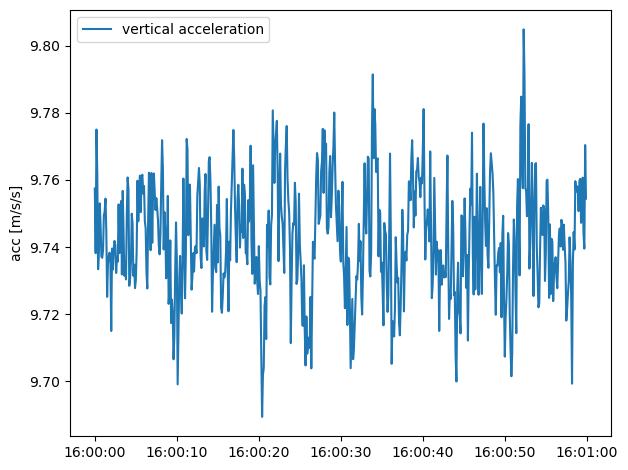

In [1]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)

fs = 10.0
ts = 1.0 / fs
n_points_plot = int(60 * fs)

plt.figure()
plt.plot(data["datetime"].to_numpy()[0:n_points_plot], data["VN1002_acc_d_m/s/s"].to_numpy()[0:n_points_plot], label="vertical acceleration")
plt.ylabel("acc [m/s/s]")
plt.legend()
plt.tight_layout()
plt.show()

### Quick look at data properties: Gaussian distribution

Note that there is a twist: for large real world samples, the Gaussian test becomes very powerful (very good at finding the smallest deviation from gaussianity), so it will usually fail in practice (find any slightly non gaussian deviation).

So in practice for large sample sizes, prefer looking at a Q-Q plot, and checking skewness and kurtosis. A Gaussian histogram / Q-Q plot only checks the *marginal* distribution of $x(t)$. The $\chi^2$ periodogram law is for a Gaussian *process* (jointly Gaussian samples, or DFT bins that are approximately Gaussian). A near-Gaussian marginal is the usual practical check, but it is not sufficient by itself.

A statistical test for normal distribution nearly always fail on large datasets


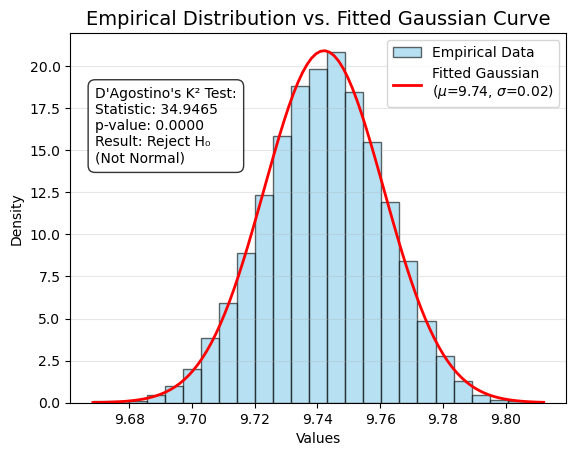


In practice, the data are near Gaussian


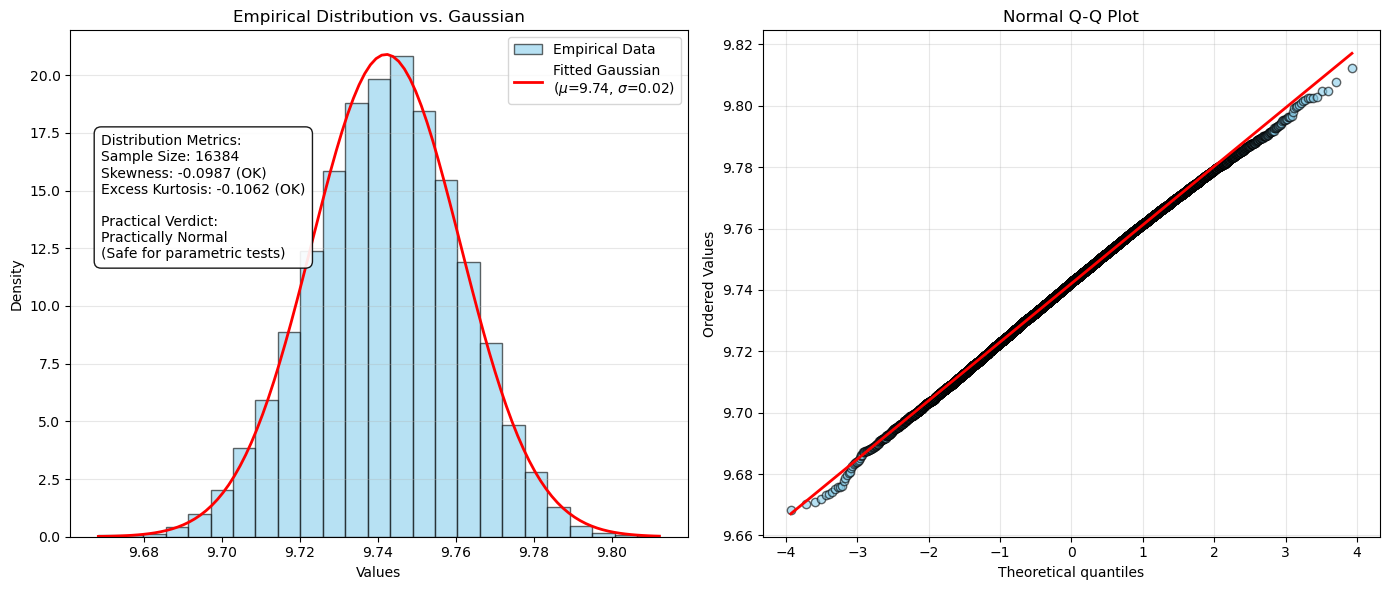

In [2]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# ---

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()

# ---

print("A statistical test for normal distribution nearly always fail on large datasets")

mu, sigma = stats.norm.fit(data)
agostino_stat, p_value = stats.normaltest(data)

test_results = f"D'Agostino's K² Test:\nStatistic: {agostino_stat:.4f}\np-value: {p_value:.4f}\n"
if p_value > 0.05:
    test_results += "Result: Fail to reject H₀\n(Likely Normal)"
else:
    test_results += "Result: Reject H₀\n(Not Normal)"

x = np.linspace(min(data), max(data), 100)
gaussian_pdf = stats.norm.pdf(x, mu, sigma)

plt.figure()
count, bins, ignored = plt.hist(data, bins=25, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical Data')
plt.plot(x, gaussian_pdf, 'r-', linewidth=2, label=f'Fitted Gaussian\n($\mu$={mu:.2f}, $\sigma$={sigma:.2f})')
plt.text(0.05, 0.65, test_results, transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
plt.title('Empirical Distribution vs. Fitted Gaussian Curve', fontsize=14)
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ---

print("")
print("In practice, the data are near Gaussian")

mu, sigma = stats.norm.fit(data)
skewness = stats.skew(data)
ex_kurtosis = stats.kurtosis(data)

is_skew_ok = -1.0 <= skewness <= 1.0
is_kurt_ok = -2.0 <= ex_kurtosis <= 2.0

shape_results = (
    f"Distribution Metrics:\n"
    f"Sample Size: {len(data)}\n"
    f"Skewness: {skewness:.4f} ({'OK' if is_skew_ok else 'High'})\n"
    f"Excess Kurtosis: {ex_kurtosis:.4f} ({'OK' if is_kurt_ok else 'High'})\n\n"
    f"Practical Verdict:\n"
)
if is_skew_ok and is_kurt_ok:
    shape_results += "Practically Normal\n(Safe for parametric tests)"
else:
    shape_results += "Non-Normal Shape\n(Consider transformations)"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Left Subplot: Histogram + Fit
count, bins, ignored = ax1.hist(
    data,
    bins=25,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
    label="Empirical Data",
)
x = np.linspace(min(data), max(data), 100)
ax1.plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    "r-",
    linewidth=2,
    label=f"Fitted Gaussian\n($\mu$={mu:.2f}, $\sigma$={sigma:.2f})",
)
ax1.text(
    0.05,
    0.55,
    shape_results,
    transform=ax1.transAxes,
    bbox=dict(facecolor="white", alpha=0.9, boxstyle="round,pad=0.5"),
)
ax1.set_title("Empirical Distribution vs. Gaussian", fontsize=12)
ax1.set_xlabel("Values")
ax1.set_ylabel("Density")
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.3)

# Right Subplot: Q-Q Plot
stats.probplot(data, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor("skyblue")
ax2.get_lines()[0].set_markeredgecolor("black")
ax2.get_lines()[0].set_alpha(0.6)
ax2.get_lines()[1].set_color("red")
ax2.get_lines()[1].set_linewidth(2)
ax2.set_title("Normal Q-Q Plot", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Quick look at data properties: autocorrelation

Note that for a narrow band signal, one will always observe some weak "correlation echoes" at multiples of the main band. Typically there is no significant autocorrelation once the ACF has dropped to near 0 and afterwards shows only small ripples. The red curve is the Hilbert envelope of the *one-sided* (positive-lag) ACF: a visual aid for that decay, not a theorem. Use it to see when the ACF has died, then choose segments comfortably longer than that time.

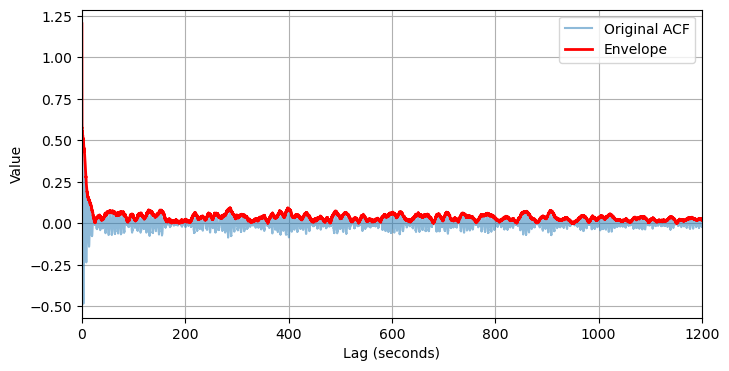

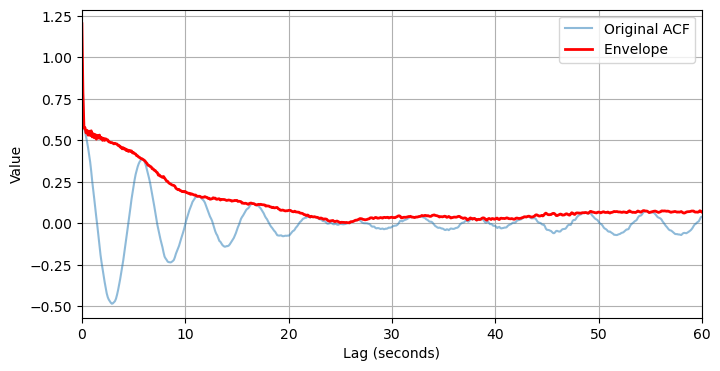

In [3]:
%reset -f

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0

data_centered = data - np.mean(data)
acf = np.correlate(data_centered, data_centered, mode='full')[len(data)-1:]
normalized_acf = acf / acf[0]

lags_time = np.arange(len(normalized_acf)) / fs

# Hilbert envelope of the one-sided ACF: visualization of decay, not a formal test
analytic_signal = hilbert(normalized_acf)
amplitude_envelope = np.abs(analytic_signal)

plt.figure(figsize=(8, 4))
plt.plot(lags_time, normalized_acf, label='Original ACF', alpha=0.5)
plt.plot(lags_time, amplitude_envelope, label='Envelope', color='red', linewidth=2)
plt.xlabel("Lag (seconds)")
plt.ylabel("Value")
plt.legend()
plt.xlim([0, 1200])
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lags_time, normalized_acf, label='Original ACF', alpha=0.5)
plt.plot(lags_time, amplitude_envelope, label='Envelope ', color='red', linewidth=2)
plt.xlabel("Lag (seconds)")
plt.ylabel("Value")
plt.legend()
plt.xlim([0, 60])
plt.grid(True)
plt.show()

### Quick look at data properties: stationarity

Naturally, this is a bit noisy - but observe there are no trends; we took a window duration based on the number of points (for fast FFT radix 2), that is well above the 30 seconds from above - this is depending on the tradeoffs we want.

time window duration: 204.8 s.


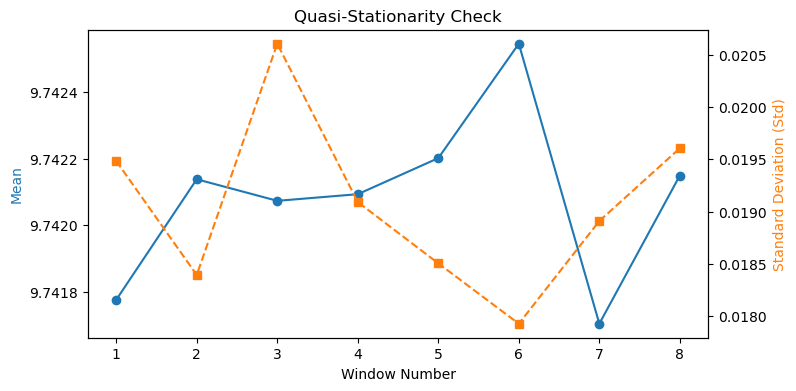

In [4]:
%reset -f

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0
win_dur = len(data) / 2**3 / fs

print(f"time window duration: {win_dur} s.")

win_samples = int(win_dur * fs)
num_wins = len(data) // win_samples
windows = data[:num_wins * win_samples].reshape(num_wins, win_samples)

means = np.mean(windows, axis=1)
stds = np.std(windows, axis=1)
x = np.arange(1, num_wins + 1)

# 3. Plot the metrics
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(x, means, 'o-', color='tab:blue', label='Mean')
ax2.plot(x, stds, 's--', color='tab:orange', label='Std')

ax1.set_xlabel('Window Number')
ax1.set_ylabel('Mean', color='tab:blue')
ax2.set_ylabel('Standard Deviation (Std)', color='tab:orange')
plt.title('Quasi-Stationarity Check')
plt.show()

### Welch estimator

We are now ready to do a Welch estimate, with error bars. The noise level is obtained as a combination of the accelerometer built into the VN100 and the Kalman filtering run on the fly, so it does not match the "individual accelerometer datasheet", but we estimate it visually from the plot. As is visible here, the main and secondary (harmonic) lobes are clearly well resolved and real: they are both well above the noise level of the measurements taking into account the error bars.

effective degrees of freedom in the chi-square: 28.52112676056338 .


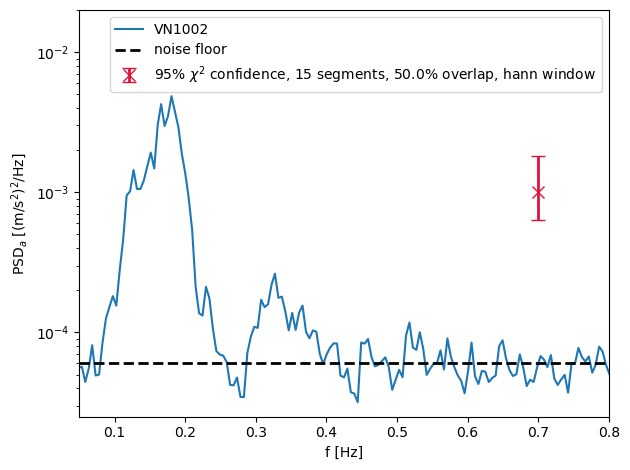

In [5]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt
from scipy import signal
import scipy.stats as stats
import numpy as np

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0

window = "hann"
nperseg = int(len(data) / 2**3)
noverlap = int(nperseg / 2)  # 50% overlap
overlap = noverlap / nperseg
nfft = nperseg
detrend = "constant"
return_onesided = True
scaling = "density"
average = "mean"
p = (len(data) - noverlap) // (nperseg - noverlap)
edf = 36 * p**2 / (19 * p - 1)

print(f"effective degrees of freedom in the chi-square: {edf} .")

crrt_f, crrt_welch_psd_acc_d = signal.welch(
    data,
    fs=fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    detrend=detrend,
    return_onesided=return_onesided,
    scaling=scaling,
    average=average
)

alpha = 0.05
lower_chi = stats.chi2.ppf(alpha / 2, df=edf)
upper_chi = stats.chi2.ppf(1 - alpha / 2, df=edf)
scale_lower = edf / upper_chi
scale_upper = edf / lower_chi

plt.figure()
plt.plot(crrt_f, crrt_welch_psd_acc_d, label="VN1002")
plt.axhline(6e-5, color="black", linewidth=2.0, linestyle="--", label="noise floor")

x_cross = 0.7        
y_cross = 1e-3

y_err_lower = y_cross - (y_cross * scale_lower)
y_err_upper = (y_cross * scale_upper) - y_cross
y_err = [[y_err_lower], [y_err_upper]]

plt.errorbar(x_cross, y_cross, yerr=y_err, fmt='x', color='crimson', 
             markersize=8, capsize=5, elinewidth=2, label=f'95% $\chi^2$ confidence, {p} segments, {100*overlap}% overlap, {window} window')

plt.xlim([0.05, 0.8])
plt.ylim([2.5e-5, 2e-2])

plt.xlabel("f [Hz]")
plt.ylabel("PSD$_a$ [(m/s$^2$)$^2$/Hz]")
plt.legend()

plt.semilogy()
plt.tight_layout()
plt.show()

## Bonus: going back to the source

The main reference on this is the P. Welch paper from 1967, "The Use of Fast Fourier Transform for the Estimation of Power Spectra: A Method Based on Time Averaging Over Short, Modified Periodograms".

This contains in particular the formula for computing the effective number of degrees of freedom:

$\nu_{eff} = \frac{2p}{1 + 2 \sum_{m=1}^{p-1} (1 - \frac{m}{p}) \rho^2(m \times S)}$,

where:

$p$ is the total number of overlapping segments,
$\rho(m \times S)$ is the normalized correlation coefficient between 2 segments shifted by $m$ "welch segments" steps (i.e. shifted by $m \times S$ sample points, where $S$ is how many points separate the start of one segment to the start of the next segment: $S=nperseg - noverlap$, with $nperseg$ the number of points per segment and $noverlap$ the number of ovelapping points between 2 consecutive segments), which is computed from the windowing function $w$ as:
$\rho(m \times S) = \frac{\sum_n w[n] w[n+m \times S]}{\sum_n w^2[n]}$

This is implemented as `estimate_welch_edf` in `welch_spectrum.py`. For a Hann window with 50% overlap it matches $\nu = 36 p^2 / (19 p - 1)$ used above; the general $\rho$-sum works for any taper and overlap.

In [6]:
%reset -f

import polars as pl
from welch_spectrum import estimate_welch_edf

# the same data and parameters as used above
data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0

window = "hann"
nperseg = int(len(data) / 2**3)
noverlap = int(nperseg / 2)  # 50% overlap

N_SAMPLES = len(data)
N_PER_SEG = nperseg
N_OVERLAP = noverlap
WIN_TYPE = window

nu_eff, num_segments = estimate_welch_edf(N_SAMPLES, N_PER_SEG, N_OVERLAP, window=WIN_TYPE)
hann_50 = 36 * num_segments**2 / (19 * num_segments - 1)

print(f"--- Welch Spectrum EDF Estimation ---")
print(f"Total Signal Samples : {N_SAMPLES}")
print(f"Segment Length       : {N_PER_SEG}")
print(f"Overlap Samples      : {N_OVERLAP} ({N_OVERLAP/N_PER_SEG*100:.1f}%)")
print(f"Window Type          : {WIN_TYPE}")
print(f"-------------------------------------")
print(f"Total Segments (K)   : {num_segments}")
print(f"Nominal Chi-Sq DoF   : {2 * num_segments} (If segments would be completely independent)")
print(f"Effective DoF (ν_eff): {nu_eff:.2f}")
print(f"Hann 50% formula     : {hann_50:.2f}  (should match ν_eff)")


--- Welch Spectrum EDF Estimation ---
Total Signal Samples : 16384
Segment Length       : 2048
Overlap Samples      : 1024 (50.0%)
Window Type          : hann
-------------------------------------
Total Segments (K)   : 15
Nominal Chi-Sq DoF   : 30 (If segments would be completely independent)
Effective DoF (ν_eff): 28.52
Hann 50% formula     : 28.52  (should match ν_eff)


## All-in-one helper

The same checks and Welch $\chi^2$ interval, as `welch_spectrum.welch_spectrum_with_checks_and_uncertainties`. Import that module in other projects; this cell only demonstrates it on the present record.


=== Gaussianity (large-N practical check) ===
A formal test (D'Agostino K² / KS) almost always rejects on long real records; use skew, excess kurtosis, and a Q-Q plot.
N = 16384, mean = 9.74209, std = 0.0190825
D'Agostino K² statistic = 34.9465, p = 2.579e-08 (reject Gaussian at 5%)
Skewness = -0.0987 (practical |skew| <= 1)
Excess kurtosis = -0.1062 (practical |excess kurtosis| <= 2)
Verdict: near-Gaussian marginally. Necessary, not sufficient for a Gaussian process.



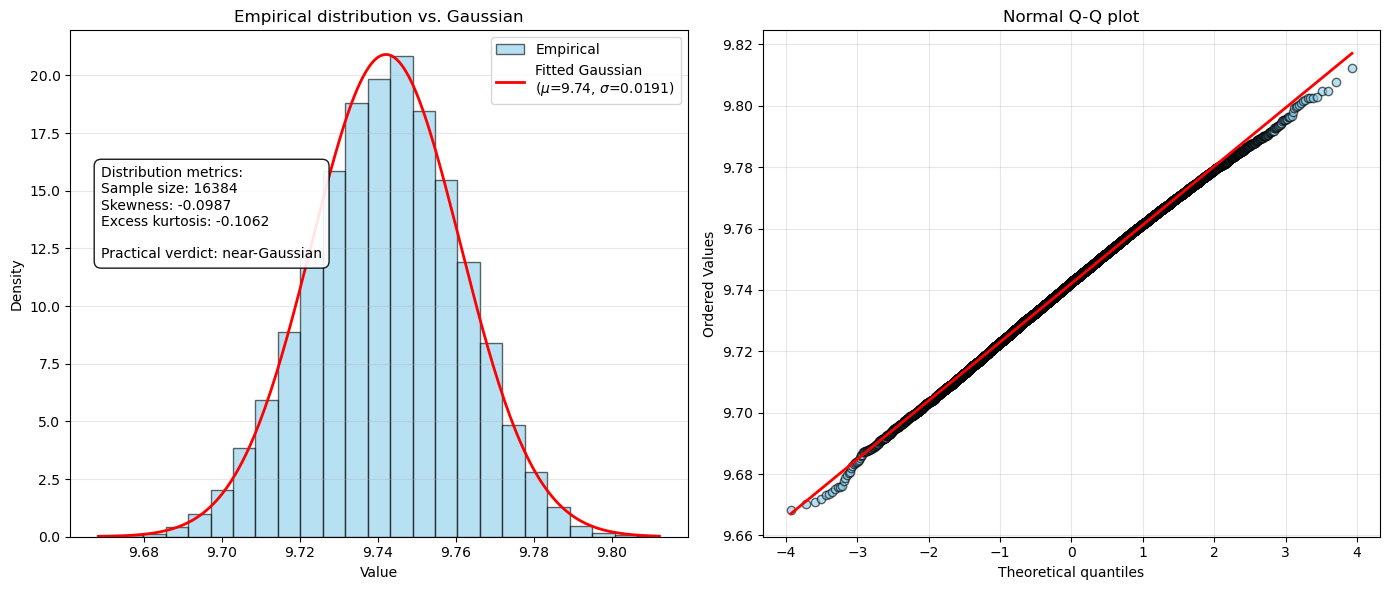

=== Autocorrelation time vs segment length ===
Envelope is the Hilbert envelope of the two-sided ACF, positive lags (visual decay, not a theorem). τ_acf = first lag where the envelope drops below 0.2.
τ_acf ≈ 9.5 s, T_seg = 204.8 s, T_seg / τ_acf = 21.6
ACF(hop) = -0.01997, ACF(T_seg) = 0.008087
Verdict: segment length is comfortably above the ACF decay time.



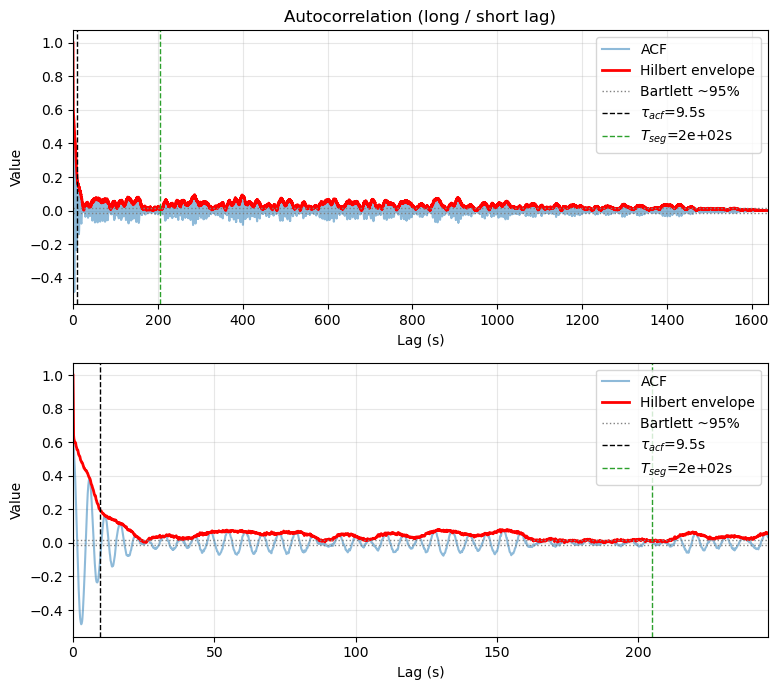

=== Stationarity (non-overlapping segments of length nperseg) ===
Mean drift is (max mean − min mean) / typical window std — use this, not the relative change of a large DC offset (e.g. gravity).
8 windows of 204.8 s
Window means: min=9.74171, max=9.74254, drift/σ = 0.044
Window stds:  min=0.0179257, max=0.0206067, range/mean = 0.141
Verdict: no large trend in mean (in σ units) or in variance.



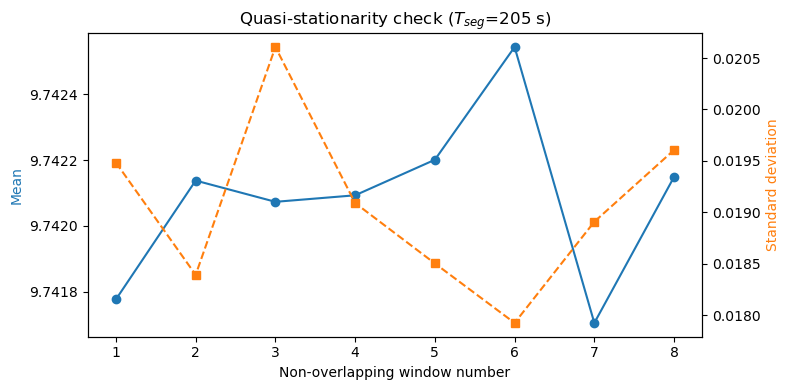

=== Welch estimate ===
window=hann, nperseg=2048, noverlap=1024 (50.0%), K=15 segments
EDF ν = 28.52  (independent segments would give 2K = 30)
95% multiplicative interval: [0.6321, 1.817] × PSD
Shaded band / factors apply to interior bins. DC and Nyquist have fewer dof. Adjacent bins are correlated (taper ENBW).



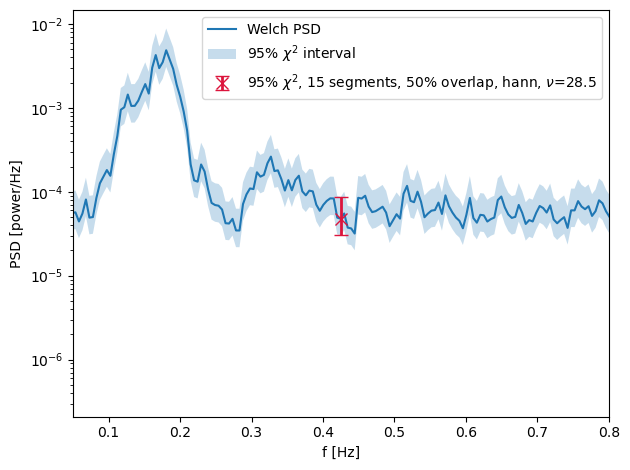

edof=28.52, scale=[0.6321, 1.817]
PSD shape=(1025,), f[0]=0, f[-1]=5


In [7]:
%reset -f

import polars as pl
from welch_spectrum import welch_spectrum_with_checks_and_uncertainties

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
x = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0
nperseg = int(len(x) / 2**3)
noverlap = nperseg // 2

(
    frequency,
    welch_spectrum,
    (low_uncertainty_factor, up_uncertainty_factor),
    (lower_welch, upper_welch),
    edof,
) = welch_spectrum_with_checks_and_uncertainties(
    x,
    sample_rate=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
    confidence_level=0.95,
    verbose=True,
    plot=True,
    freq_range=(0.05, 0.8),
)

print(f"edof={edof:.4g}, scale=[{low_uncertainty_factor:.4g}, {up_uncertainty_factor:.4g}]")
print(f"PSD shape={welch_spectrum.shape}, f[0]={frequency[0]:.4g}, f[-1]={frequency[-1]:.4g}")


## Monte Carlo checks of the $\chi^2$ interval

The Welch error bars are a statement about a **Gaussian process** with a given spectrum. A direct test is to draw many independent realizations of a process with a *known* $S(f)$, run the same Welch estimator, and compare the scatter to the $\chi^2_\nu$ law.

Two 95% bands are easy to mix up (same length on a log axis, opposite skew):

- **Law of $\hat{S}$ given $S$** (histograms and the MC percentile band): $\hat{S} \in [S\,\chi^2_{\nu,\alpha/2}/\nu,\; S\,\chi^2_{\nu,1-\alpha/2}/\nu]$.
- **CI for $S$ given $\hat{S}$** (the notebook error bars): $S \in [\nu\hat{S}/\chi^2_{\nu,1-\alpha/2},\; \nu\hat{S}/\chi^2_{\nu,\alpha/2}]$.

### How to read the CI coverage plot

For *each* Monte Carlo draw and *each* frequency we build the same interval as in the Welch section, $[\hat{S}\,\nu/\chi^2_{\nu,1-\alpha/2},\; \hat{S}\,\nu/\chi^2_{\nu,\alpha/2}]$, and ask whether the known true $S(f)$ sits inside it. The curve is that success rate versus $f$.

- If the $\chi^2_\nu$ model is right, the curve sits at $95\%$.
- Below $95\%$: the published bars are too tight (undercoverage).
- Above $95\%$: conservative (bars too wide).
- With $N_{\mathrm{MC}}$ draws, binomial jitter on a single bin is $\sim\sqrt{0.95\cdot 0.05/N_{\mathrm{MC}}}$. Hann correlates neighbouring bins, so the curve is smoother than independent coin-flips — do not over-read every wiggle.

$\hat{S}\sim S\,\chi^2_\nu/\nu$ is still **right-skewed** at our $\nu\approx 28.5$ (skewness $\sqrt{8/\nu}\approx 0.53$). A slightly longer right tail on the peak histogram is the theory, not a bug. More draws just make that shape easier to see against the red $\chi^2$ curve.

**Case i.** Gaussian process whose true spectrum is the Welch estimate from the ice record. Expect a match, up to Hann smoothing of sharp peaks.

**Case ii.** Gaussian process with the main-peak band sitting on the measured noise floor, then $y=x+\alpha x^2$ (mean removed). Without a floor the continuum PSD is $\approx 0$, so the lower MC percentile vanishes on a log plot — that was an artifact of $S=0$, not of the quadratic. The line at $2f_0$ is a quadratic of the *same* envelope, not an independent Gaussian DFT bin. The main peak and the floor should stay close to $\chi^2$; the harmonic is the interesting test.


In [8]:
%reset -f

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.stats as stats

from welch_spectrum import welch_spectrum_with_checks_and_uncertainties

# --- data + Welch settings (same as the example) ---
data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
x_obs = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0
n_signal = len(x_obs)
nperseg = int(n_signal / 2**3)
noverlap = nperseg // 2
confidence_level = 0.95
alpha = 1.0 - confidence_level
freq_range = (0.05, 0.8)
n_mc = 8000
rng = np.random.default_rng(0)

obs = welch_spectrum_with_checks_and_uncertainties(
    x_obs,
    sample_rate=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
    confidence_level=confidence_level,
    verbose=False,
    plot=False,
)
f_welch = obs.frequency
S_obs = obs.welch_spectrum
edof = obs.edof
scale_lo, scale_hi = obs.uncertainty_factors
q_lo = stats.chi2.ppf(alpha / 2.0, df=edof) / edof
q_hi = stats.chi2.ppf(1.0 - alpha / 2.0, df=edof) / edof

i_peak = int(np.argmax(np.where((f_welch >= 0.05) & (f_welch <= 0.3), S_obs, -np.inf)))
f_peak = float(f_welch[i_peak])
f_other = 0.7
f_harmonic = 2.0 * f_peak
print(f"N={n_signal}, nperseg={nperseg}, K-edof nu={edof:.3g}")
print(f"f_peak={f_peak:.4g} Hz, f_harmonic={f_harmonic:.4g} Hz, f_other={f_other} Hz")
print(f"predictive Shat/S 95% factors [{q_lo:.4g}, {q_hi:.4g}]")
print(f"CI S/Shat 95% factors         [{scale_lo:.4g}, {scale_hi:.4g}]")
print(f"chi2 skewness sqrt(8/nu)={np.sqrt(8.0/edof):.3f}  (still right-skewed; 0 would be Gaussian)")


def gaussian_process_from_onesided_psd(f, psd, n, fs, rng):
    """Real GP of length n whose scipy one-sided density is `psd` on `f`."""
    f_r = np.fft.rfftfreq(n, d=1.0 / fs)
    S_r = np.clip(np.interp(f_r, f, psd, left=0.0, right=0.0), 0.0, None)
    sigma = np.sqrt(S_r * fs * n / 2.0)
    sigma[0] *= np.sqrt(2.0)
    if n % 2 == 0:
        sigma[-1] *= np.sqrt(2.0)
    z = (rng.normal(size=sigma.shape) + 1j * rng.normal(size=sigma.shape)) / np.sqrt(2.0)
    z[0] = rng.normal()
    if n % 2 == 0:
        z[-1] = rng.normal()
    return np.fft.irfft(z * sigma, n=n)


def welch_psd(x):
    f, P = signal.welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nperseg,
        detrend="constant",
        return_onesided=True,
        scaling="density",
        average="mean",
    )
    return f, P


def monte_carlo_welch(psd_true, n_mc, rng, transform=None):
    Ps = np.empty((n_mc, f_welch.size), dtype=float)
    for i in range(n_mc):
        x = gaussian_process_from_onesided_psd(f_welch, psd_true, n_signal, fs, rng)
        if transform is not None:
            x = transform(x)
        _, P = welch_psd(x)
        Ps[i] = P
        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{n_mc}")
    return Ps


def nearest_index(freq):
    return int(np.argmin(np.abs(f_welch - freq)))


def coverage_ci(P_mc, S_true):
    """Fraction of draws whose inverted chi^2 CI contains S_true."""
    return np.mean((P_mc * scale_lo <= S_true) & (S_true <= P_mc * scale_hi), axis=0)


def plot_mc_spectrum(S_ref, P_mc, title, ref_label="reference S(f)"):
    """Dashed chi2 band is around the MC mean (centre of Shat).

    Hann-smoothed peaks have E[Shat] < generating S; centering theory on
    generating S makes the peak histogram look skewed even when chi2 is right.
    """
    p_lo = np.quantile(P_mc, alpha / 2.0, axis=0)
    p_hi = np.quantile(P_mc, 1.0 - alpha / 2.0, axis=0)
    P_mean = P_mc.mean(axis=0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(f_welch, S_ref, color="k", lw=1.5, label=ref_label)
    ax.semilogy(f_welch, P_mean, color="tab:blue", lw=1, alpha=0.8, label="MC mean")
    ax.fill_between(
        f_welch,
        np.clip(p_lo, 1e-30, None),
        p_hi,
        color="tab:blue",
        alpha=0.25,
        label=f"MC {100*confidence_level:.0f}% of Shat",
    )
    ax.semilogy(f_welch, P_mean * q_lo, color="crimson", lw=1, ls="--", label="theory 95% around MC mean")
    ax.semilogy(f_welch, P_mean * q_hi, color="crimson", lw=1, ls="--")
    for freq in (f_peak, f_harmonic, f_other):
        ax.axvline(freq, color="gray", ls=":", lw=0.8, alpha=0.8)
    ax.set_xlim(*freq_range)
    view = (f_welch >= freq_range[0]) & (f_welch <= freq_range[1])
    y_vis = np.concatenate([p_lo[view], p_hi[view], np.asarray(S_ref)[view], P_mean[view]])
    y_vis = y_vis[np.isfinite(y_vis) & (y_vis > 0)]
    ax.set_ylim(max(float(y_vis.min()) * 0.4, 1e-7), float(y_vis.max()) * 2.5)
    ax.set_xlabel("f [Hz]")
    ax.set_ylabel("PSD [power/Hz]")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_histograms(S_true, P_mc, freqs, title):
    fig, axes = plt.subplots(1, len(freqs), figsize=(4.6 * len(freqs), 4.4), sharey=False)
    if len(freqs) == 1:
        axes = [axes]
    sk_th = float(np.sqrt(8.0 / edof))
    for ax, freq in zip(axes, freqs):
        k = nearest_index(freq)
        samples = P_mc[:, k]
        S_mean = float(samples.mean())
        S_refk = float(S_true[k])
        xmax = max(np.quantile(samples, 0.995), S_mean * q_hi * 1.15)
        grid = np.linspace(0.0, xmax, 400)
        pdf = (
            stats.chi2.pdf(grid * edof / S_mean, df=edof) * (edof / S_mean)
            if S_mean > 0
            else np.zeros_like(grid)
        )
        ax.hist(samples, bins=40, density=True, color="skyblue", edgecolor="black", alpha=0.75, label="MC")
        ax.plot(grid, pdf, color="crimson", lw=2, label="chi2 around MC mean")
        ax.axvline(S_mean, color="tab:blue", lw=1.5, label="MC mean")
        if S_refk > 0 and abs(S_refk - S_mean) / max(S_mean, 1e-30) > 0.03:
            ax.axvline(S_refk, color="k", lw=1.2, ls="--", label="generating S")
        sk_mc = float(stats.skew(samples))
        ax.set_xlabel("Shat")
        ax.set_title(f"f = {f_welch[k]:.3g} Hz\nskew MC={sk_mc:.2f}, chi2={sk_th:.2f}")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("density")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_coverage(S_true, P_mc, title):
    cov = coverage_ci(P_mc, S_true)
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(f_welch, cov, color="tab:blue", lw=1.2)
    ax.axhline(confidence_level, color="k", ls="--", lw=1, label=f"target {100*confidence_level:.0f}%")
    for freq in (f_peak, f_harmonic, f_other):
        ax.axvline(freq, color="gray", ls=":", lw=0.8, alpha=0.8)
    ax.set_xlim(*freq_range)
    band = (f_welch >= freq_range[0]) & (f_welch <= freq_range[1])
    ax.set_ylim(min(0.7, float(np.min(cov[band])) - 0.05), 1.02)
    ax.set_xlabel("f [Hz]")
    ax.set_ylabel("CI coverage")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()
    print(f"mean CI coverage in {freq_range}: {cov[band].mean():.3f}")


print(f"\nRunning {n_mc} linear GP realizations...")
P_linear = monte_carlo_welch(S_obs, n_mc, rng)

# Case ii: main lobe on the measured noise floor + quadratic.
# A hard-zero continuum makes Shat's lower tail ~0 and the log-plot dives.
noise_floor = float(np.median(S_obs[(f_welch >= 0.5) & (f_welch <= 0.8)]))
S_main = np.where((f_welch >= 0.08) & (f_welch <= 0.26), S_obs, noise_floor)
alpha_nl = 25.0
print(f"case ii noise floor = {noise_floor:.4e}")


def quadratic(x):
    y = x + alpha_nl * x**2
    return y - np.mean(y)


print(f"Running {n_mc} quadratic realizations (alpha={alpha_nl})...")
P_quad = monte_carlo_welch(S_main, n_mc, rng, transform=quadratic)
S_quad_ref = P_quad.mean(axis=0)
print("MC done.")


N=16384, nperseg=2048, K-edof nu=28.5
f_peak=0.1807 Hz, f_harmonic=0.3613 Hz, f_other=0.7 Hz
predictive Shat/S 95% factors [0.5502, 1.582]
CI S/Shat 95% factors         [0.6321, 1.817]
chi2 skewness sqrt(8/nu)=0.530  (still right-skewed; 0 would be Gaussian)

Running 8000 linear GP realizations...
  500/8000
  1000/8000
  1500/8000
  2000/8000
  2500/8000
  3000/8000
  3500/8000
  4000/8000
  4500/8000
  5000/8000
  5500/8000
  6000/8000
  6500/8000
  7000/8000
  7500/8000
  8000/8000
case ii noise floor = 5.6532e-05
Running 8000 quadratic realizations (alpha=25.0)...
  500/8000
  1000/8000
  1500/8000
  2000/8000
  2500/8000
  3000/8000
  3500/8000
  4000/8000
  4500/8000
  5000/8000
  5500/8000
  6000/8000
  6500/8000
  7000/8000
  7500/8000
  8000/8000
MC done.


### Case i — Gaussian process with the observed spectrum

True $S(f)$ is the Welch estimate from the record. Each draw is a new GP realization of the same length, then the same Hann / 50% / $n_{\mathrm{perseg}}$ Welch.

On semilogy the blue band is the MC 2.5–97.5% of $\hat{S}$. Dashed lines are the $\chi^2$ band **around the MC mean** (the actual centre of $\hat{S}$). The black curve is the generating $S(f)$; at a sharp peak Hann bias makes it sit above the MC mean — that shift is not skew. Vertical dotted lines mark $f_0$, $2f_0$, and $0.7\,\mathrm{Hz}$.

Histograms at those three frequencies. A mild **right skew** at the peak is expected ($\sqrt{8/\nu}\approx 0.53$); the title compares MC skew to that $\chi^2$ value.

The coverage panel is the fraction of draws whose *inverted* $\chi^2$ CI contains the true $S$ — the same interval as the crimson error bar in the Welch section. It should hug $95\%$ if that bar is calibrated.


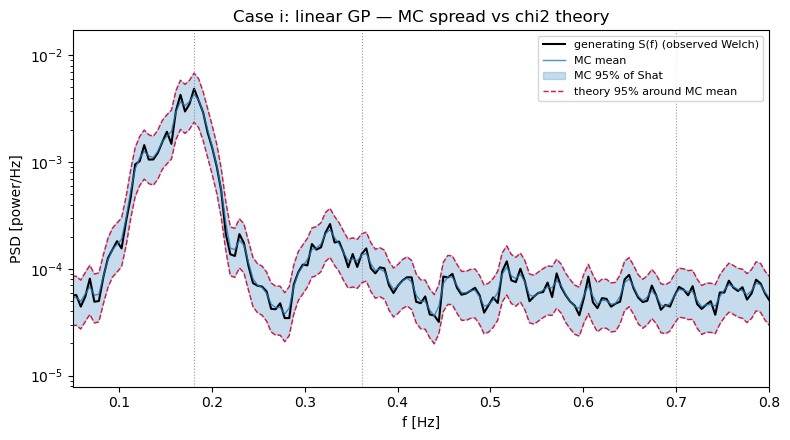

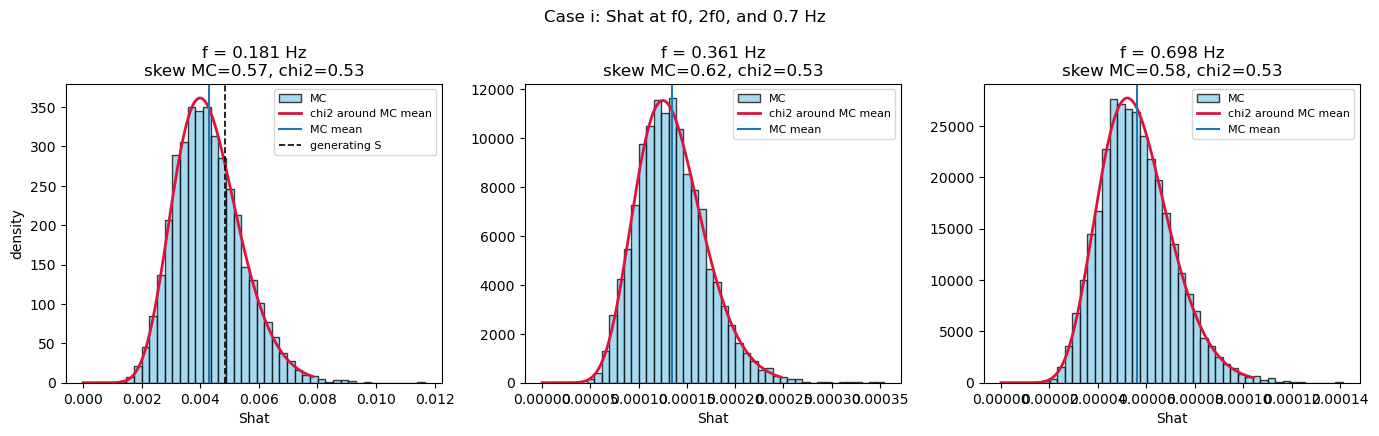

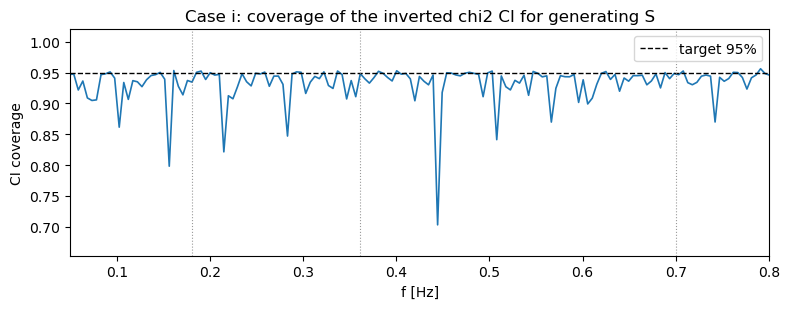

mean CI coverage in (0.05, 0.8): 0.932
case i  (coverage vs generating S; std/mean and skew of Shat)
f0       coverage=0.934  std/mean=0.270 (chi2 0.265)  skew=0.57 (chi2 0.53)  mean/S=0.884
2f0      coverage=0.948  std/mean=0.267 (chi2 0.265)  skew=0.62 (chi2 0.53)  mean/S=0.974
0.7 Hz   coverage=0.949  std/mean=0.268 (chi2 0.265)  skew=0.58 (chi2 0.53)  mean/S=0.999


In [9]:
plot_mc_spectrum(S_obs, P_linear, "Case i: linear GP — MC spread vs chi2 theory",
                 ref_label="generating S(f) (observed Welch)")
plot_histograms(S_obs, P_linear, (f_peak, f_harmonic, f_other), "Case i: Shat at f0, 2f0, and 0.7 Hz")
plot_coverage(S_obs, P_linear, "Case i: coverage of the inverted chi2 CI for generating S")

sk_th = np.sqrt(8.0 / edof)
rel_th = np.sqrt(2.0 / edof)
print("case i  (coverage vs generating S; std/mean and skew of Shat)")
for lab, freq in (("f0", f_peak), ("2f0", f_harmonic), ("0.7 Hz", f_other)):
    k = nearest_index(freq)
    cov = coverage_ci(P_linear, S_obs)[k]
    rel = P_linear[:, k].std() / P_linear[:, k].mean()
    sk = stats.skew(P_linear[:, k])
    print(f"{lab:7s}  coverage={cov:.3f}  std/mean={rel:.3f} (chi2 {rel_th:.3f})  skew={sk:.2f} (chi2 {sk_th:.2f})  mean/S={P_linear[:, k].mean()/S_obs[k]:.3f}")


### Case ii — main peak plus $y=x+\alpha x^2$

The generating spectrum is the observed main lobe ($0.08$–$0.26\,\mathrm{Hz}$) sitting on the measured high-frequency noise floor. A linear GP with that $S(f)$ has no extra $2f_0$ line; $x^2$ supplies DC and a harmonic. Because $x^2$ is a function of the *same* narrow-band envelope, $\hat{S}(2f_0)$ is not an independent $\chi^2_\nu$ bin.

The previous version zeroed the continuum. Then $\mathbb{E}[\hat{S}]$ there is only leakage, the $2.5\%$ MC quantile is tiny, and a semilogy plot looks like it falls off the bottom. That was $S\approx 0$, not a mystery of the quadratic.

Reference $S(f)$ for the theory curves is the **MC mean** of $\hat{S}$ (mean spectrum of $y$, including the harmonic and leakage). If the Gaussian-process error bars still applied, coverage would stay $\approx 95\%$ at $2f_0$ and the histogram would match $S\chi^2_\nu/\nu$. There is no theorem that says they should.

With a few thousand draws the harmonic at $2f_0$ is **statistically clearly not** $\chi^2_\nu$: skew and std/mean sit above the Gaussian-process values, and CI coverage is a bit under $95\%$. The mismatch is real, but modest (coverage still $\sim 90\%$, width only tens of percent off). For most purposes the Gaussian / $\chi^2$ error bar, though not formally correct on a nonlinear harmonic, is still not so bad.


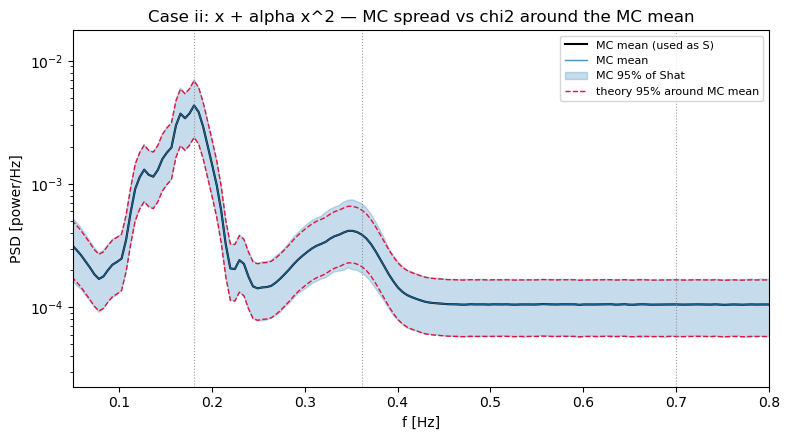

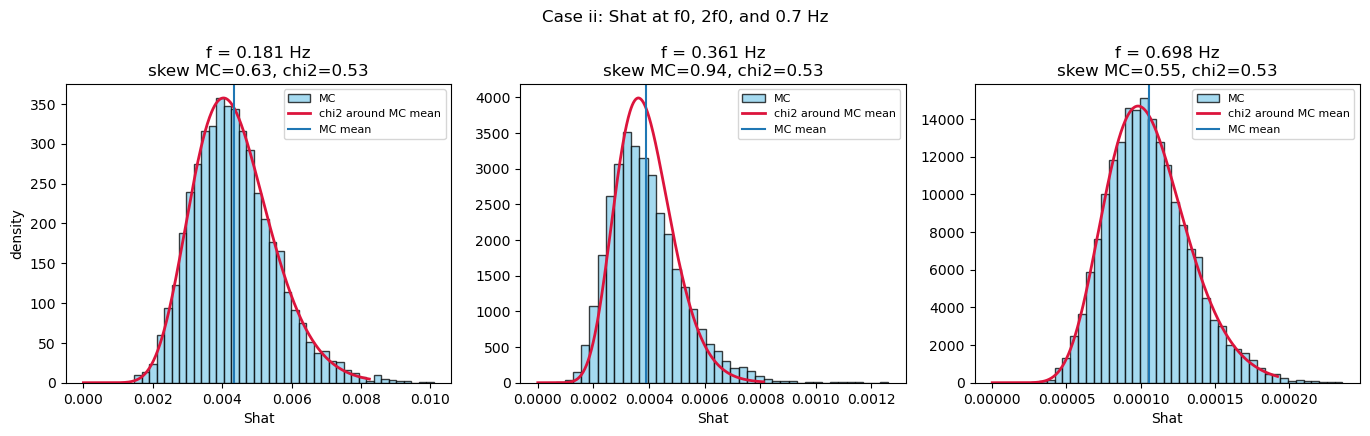

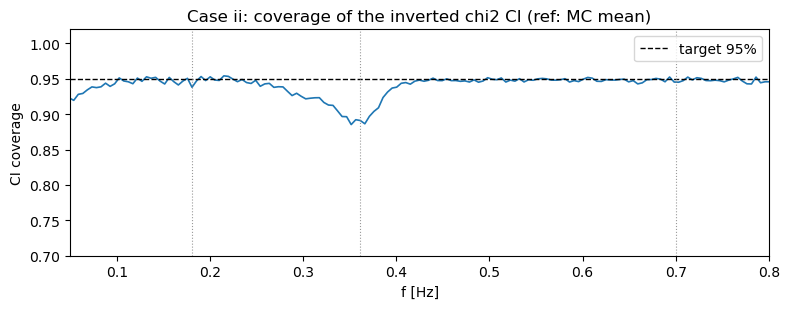

mean CI coverage in (0.05, 0.8): 0.941
noise floor used in generating S: 5.6532e-05
S_mean(f0)=4.3423e-03, S_mean(2f0)=3.8904e-04, ratio=0.090
case ii  (coverage vs MC mean; std/mean and skew of Shat)
f0       coverage=0.938  std/mean=0.274 (chi2 0.265)  skew=0.63 (chi2 0.53)
2f0      coverage=0.891  std/mean=0.333 (chi2 0.265)  skew=0.94 (chi2 0.53)
0.7 Hz   coverage=0.946  std/mean=0.267 (chi2 0.265)  skew=0.55 (chi2 0.53)


In [10]:
plot_mc_spectrum(S_quad_ref, P_quad, "Case ii: x + alpha x^2 — MC spread vs chi2 around the MC mean",
                 ref_label="MC mean (used as S)")
plot_histograms(S_quad_ref, P_quad, (f_peak, f_harmonic, f_other), "Case ii: Shat at f0, 2f0, and 0.7 Hz")
plot_coverage(S_quad_ref, P_quad, "Case ii: coverage of the inverted chi2 CI (ref: MC mean)")

k0, k2, k7 = nearest_index(f_peak), nearest_index(f_harmonic), nearest_index(f_other)
sk_th = np.sqrt(8.0 / edof)
rel_th = np.sqrt(2.0 / edof)
print(f"noise floor used in generating S: {noise_floor:.4e}")
print(f"S_mean(f0)={S_quad_ref[k0]:.4e}, S_mean(2f0)={S_quad_ref[k2]:.4e}, ratio={S_quad_ref[k2]/S_quad_ref[k0]:.3f}")
print("case ii  (coverage vs MC mean; std/mean and skew of Shat)")
for lab, k in (("f0", k0), ("2f0", k2), ("0.7 Hz", k7)):
    cov = coverage_ci(P_quad, S_quad_ref)[k]
    rel = P_quad[:, k].std() / P_quad[:, k].mean()
    sk = stats.skew(P_quad[:, k])
    print(f"{lab:7s}  coverage={cov:.3f}  std/mean={rel:.3f} (chi2 {rel_th:.3f})  skew={sk:.2f} (chi2 {sk_th:.2f})")


### What these two tests are saying

**Case i (linear GP).** Calibration of the error bars you would actually publish. The generating process is Gaussian with the observed $S(f)$, so $\chi^2_\nu$ is the truth.

- The MC percentile band should sit on the dashed theory curves (log-width set by $\nu$, not by $S$).
- Histograms at $f_0$, $2f_0$, and $0.7\,\mathrm{Hz}$ should follow $S\chi^2_\nu/\nu$, including a mild **right skew** ($\sqrt{8/\nu}\approx 0.53$ at $\nu\approx 28.5$). That is expected: $\nu$ is large enough that $\hat{S}$ is no longer exponential, not large enough to look Gaussian. Width mismatch $\Rightarrow$ $\nu$ is wrong; shape mismatch with several thousand draws $\Rightarrow$ the Gaussian-process assumption is the suspect.
- Coverage of the inverted CI should average $\approx 0.95$ across the plotted band. A small **coverage** dip at the peak is often Hann smoothing: generating $S$ on the Welch grid is not exactly $\mathbb{E}[\hat{S}]$, so the inverted CI is asked to cover the wrong centre. The histograms and dashed bands are centred on the MC mean so that Hann bias is not mistaken for extra skew.

In this linear world $2f_0$ is just another frequency that happens to have little energy in the ice spectrum. It is *not* a harmonic; it should behave like $0.7\,\mathrm{Hz}$.

**Case ii (quadratic).** $f_0$ and the noise floor stay close to $\chi^2$ (coverage $\approx 94\%$, width and skew near theory). The harmonic at $2f_0$ is **statistically significantly non-Gaussian**: skew $\sim 0.9$ vs $0.53$, std/mean $\sim 0.33$ vs $0.27$, CI coverage $\sim 89\%$ vs $95\%$. That is a real rejection of the Gaussian-process law, as expected for $x^2$ of the same envelope.

It is also not a disaster. The published $\chi^2$ bar is only modestly too tight there — still the right order of magnitude, still overlapping the bulk of the Monte Carlo scatter. For most purposes the Gaussian estimation, though not formally correct on a nonlinear harmonic, is still not so bad. Use it on the main peak and the floor without worry; on a harmonic, keep the extra grain of salt, not a different error model unless the application is high-stakes.

Practical takeaway for the ice record: the crimson $\chi^2$ bar is the right object on the **main peak and the floor** if the acceleration is close to Gaussian. A secondary lobe that is really a Stokes / ice harmonic is allowed to sit a bit outside that story, but in this $\alpha$ and Welch averaging it does not break the error bar.
